## Importig Libraries

In [16]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from tqdm import tqdm
from sklearn.metrics import accuracy_score

import os
import matplotlib.pyplot as plt



In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Getting Dataset

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [19]:
# Spectrogram Data Directory
IMG_SIZE = 224
transform_train = transforms.Compose(
    [transforms.Resize(size = (IMG_SIZE,IMG_SIZE)),
     transforms.TrivialAugmentWide(num_magnitude_bins=31),
     transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ]
)

transform_test_val = transforms.Compose(
    [transforms.Resize(size = (IMG_SIZE,IMG_SIZE)),
     transforms.TrivialAugmentWide(num_magnitude_bins=31),
     transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ]
)


train_data = datasets.ImageFolder(root ='/kaggle/input/chest-xray-pneumonia/chest_xray/train',
                                      transform = transform_train,
                                      target_transform =None)


val_data = datasets.ImageFolder(root ='/kaggle/input/chest-xray-pneumonia/chest_xray/val',
                                      transform = transform_test_val,
                                      target_transform =None)



test_data = datasets.ImageFolder(root ='/kaggle/input/chest-xray-pneumonia/chest_xray/test',
                                      transform = transform_test_val,
                                      target_transform =None)


train_data, test_data, val_data

(Dataset ImageFolder
     Number of datapoints: 5216
     Root location: /kaggle/input/chest-xray-pneumonia/chest_xray/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 624
     Root location: /kaggle/input/chest-xray-pneumonia/chest_xray/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset

In [20]:
print(train_data.classes)         # List of class names (e.g., ['NORMAL', 'PNEUMONIA'])
print(train_data.class_to_idx)    # Mapping from class names to numeric labels


['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [21]:
print(f"Total training samples: {len(train_data)}")
print(f"Total testing samples: {len(test_data)}")

Total training samples: 5216
Total testing samples: 624


In [22]:
BATCH_SIZE = 32
NUM_OF_WORKERS = os.cpu_count()

train_loader = DataLoader(train_data, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True,
                         num_workers = NUM_OF_WORKERS)
test_loader = DataLoader(test_data,
                         batch_size=BATCH_SIZE,
                         shuffle = False,
                        num_workers = NUM_OF_WORKERS)

val_loader = DataLoader(val_data,
                         batch_size=BATCH_SIZE,
                         shuffle = False,
                        num_workers = NUM_OF_WORKERS)

## Checking the imbalancing

In [23]:
from collections import Counter

# Assuming train_loader.dataset.targets exists
class_counts = Counter(train_loader.dataset.targets)
print("Class distribution:", class_counts)


Class distribution: Counter({1: 3875, 0: 1341})


In [24]:
classes = train_data.classes
classes

['NORMAL', 'PNEUMONIA']

### Visulaizing the data

torch.Size([32, 3, 224, 224])


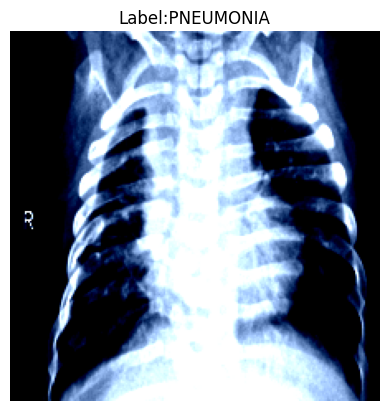

In [25]:
img, labels = next(iter(train_loader))
print(img.shape)
plt.imshow(img[0].permute(1, 2, 0))
plt.title(f'Label:{classes[labels[0]]}')
plt.axis('off')
plt.show()

# ViT
* The configuration are fully similar to the origial ViT in the Paper

In [26]:
import torch
import torch.nn as nn


class PatchPosClassEmbeddings(nn.Module):
    def __init__(self, in_channels=3,
                 patch_size=16,
                 embed_dim=768,
                 image_size=224):
        super(PatchPosClassEmbeddings, self).__init__()

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.numb_patches = (image_size // patch_size) ** 2

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embed_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_emb = nn.Parameter(torch.randn(1, self.numb_patches + 1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        image_res = int(x.shape[-1])
        assert image_res % self.patch_size == 0, "Image size must be divisible by patch size"

        x_conv = self.patcher(x)              # [B, embed_dim, H', W']
        x_flat = self.flatten(x_conv)         # [B, embed_dim, N]
        x_perm = x_flat.permute(0, 2, 1)      # [B, N, embed_dim]

        cls_token = self.class_token.expand(B, -1, -1)    # [B, 1, embed_dim]
        x_cat = torch.cat([cls_token, x_perm], dim=1)     # [B, N+1, embed_dim]

        x_pos_patch = x_cat + self.pos_emb                # [B, N+1, embed_dim]
        return x_pos_patch


### 2. Transformer Encoder

class TransformerEncoder(nn.Module):
    def __init__(self,
                embed_dim = 768,
                num_heads = 12,# from paper
                mlp_size = 3072, # hidden unit size
                mlp_dropout = 0.1# from paper
                 ):
        super().__init__()
        # layer norm + MSA
        self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
        self.multihead_atn = nn.MultiheadAttention(embed_dim = embed_dim,
                                                  num_heads = num_heads,
                                                  dropout = 0,
                                                  batch_first = True)
        # layer norm(already written above) +MLP
        self.mlp = nn.Sequential(
            nn.Linear(in_features = embed_dim,
                     out_features = mlp_size),
            nn.GELU(),
            nn.Dropout(p = mlp_dropout),
            nn.Linear(in_features = mlp_size,
                     out_features = embed_dim),
            nn.Dropout(p = mlp_dropout)
        )
        
    def forward(self,x):
        x_residul1 = x
        x_norm1 = self.layer_norm(x)
        x_msa_out,_ = self.multihead_atn(query = x_norm1,
                                       key = x_norm1, 
                                       value = x_norm1)  # adding residual connection
        x_msa_out_with_res = x_msa_out + x_residul1
        x_residual2 =  x_msa_out_with_res
        x_norm2 = self.layer_norm(x_msa_out_with_res)
        x_mlp_out_res = self.mlp(x_norm2) + x_residual2
        return x_mlp_out_res
        
        
### 3 ViT model

class Vit(nn.Module):
    def __init__(self,
                img_size: int=224,
                in_channels: int = 3,
                patch_size : int = 16,
                num_transformer_layer: int = 12,
                embed_dim: int = 768,
                mlp_size : int = 3072,
                num_heads: int = 12,
                atn_dropout: int = 0,
                mlp_dropout: int = 0.1,
                embed_dropout: int = 0.1,
                num_classes : int = 1000):
        super().__init__()
        # make assertion for image size
        assert img_size % patch_size == 0
        # Calculating number of patchs
        self.N = (img_size*img_size)// patch_size**2

        #Embedding Droput
        self.embedding_droput = nn.Dropout(p = embed_dropout )

        # Patch_embedding
        self.patch_embediing = PatchPosClassEmbeddings(in_channels = in_channels,
                                                        patch_size=patch_size,
                                                        embed_dim=embed_dim,
                                                        image_size=img_size)
        # Transformer encoder block
        self.transformer_encoder = nn.Sequential(*[TransformerEncoder(
                                                    embed_dim = 768,
                                                    num_heads = num_heads,# from paper
                                                    mlp_size = mlp_size, # hidden unit size
                                                    mlp_dropout = mlp_dropout# from paper
                                                    ) for _ in range(num_transformer_layer)])
        # creating classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape = embed_dim),
            nn.Linear(in_features = embed_dim,
                     out_features = num_classes)
            
        )

    def forward(self, x):
        x = self.patch_embediing(x)
        x = self.embedding_droput(x)
        x = self.transformer_encoder(x)
        # put 0th index logit through classifier()
        x = self.classifier(x[:,0])
        return x

In [27]:
from torchinfo import summary
model = Vit(num_classes = 2) 
summary(model,input_size = (1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
Vit                                      [1, 2]                    --
├─PatchPosClassEmbeddings: 1-1           [1, 197, 768]             152,064
│    └─Conv2d: 2-1                       [1, 768, 14, 14]          590,592
│    └─Flatten: 2-2                      [1, 768, 196]             --
├─Dropout: 1-2                           [1, 197, 768]             --
├─Sequential: 1-3                        [1, 197, 768]             --
│    └─TransformerEncoder: 2-3           [1, 197, 768]             --
│    │    └─LayerNorm: 3-1               [1, 197, 768]             1,536
│    │    └─MultiheadAttention: 3-2      [1, 197, 768]             2,362,368
│    │    └─LayerNorm: 3-3               [1, 197, 768]             (recursive)
│    │    └─Sequential: 3-4              [1, 197, 768]             4,722,432
│    └─TransformerEncoder: 2-4           [1, 197, 768]             --
│    │    └─LayerNorm: 3-5               [1, 197,

### Training the model
* optmizer : Adam (beta1, beta2 = 0.8, 0.999; weightdecay = 0.1)

In [28]:
######### ALrounder Training Loop#############################################################

# Path to save the model
save_path = "model_checkpoint.pth"
best_model_path = "best_model.pth"

def model_train(model, train_loader, val_loader, loss_fn, optimizer, epochs):
    
    epoch_count = []
    train_loss_values = []
    train_acc_values = []
    val_loss_values = []
    val_acc_values = []

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val_acc = 0.0
    
    for epoch in tqdm(range(epochs), desc="Training", leave=False):
      model.train()
      train_loss = 0.0
      train_acc = 0.0
    
      for batch, (X_train, y_train) in enumerate(train_loader):
        X_train, y_train = X_train.to(device), y_train.to(device)
          
        # Forward PAss
        y_logits = model(X_train)
        y_pred = torch.argmax(torch.softmax(y_logits, dim = 1), dim = 1)
    
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_score(y_train.cpu().numpy(),
                             y_pred.cpu().numpy())
        # Backward PAss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_loss +=loss.item()
        train_acc += acc
      train_loss = train_loss / len(train_loader)
      train_acc = train_acc / len(train_loader)
      epoch_count.append(epoch)
      train_loss_values.append(train_loss)
      train_acc_values.append(train_acc)

      #### Validation acc and Loss calculation

      val_acc, val_loss = evaluate_model(model, val_loader, loss_fn)
      val_loss_values.append(val_loss)
      val_acc_values.append(val_acc)
      
      tqdm.write(f"Epoch: {epoch}\n-------")
      tqdm.write(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
      tqdm.write(f"Validation Loss: {val_loss:.4f} | Validation Acc: {val_acc:.4f}")
        
      # Save best model
      if val_acc > best_val_acc:
          best_val_acc = val_acc
          torch.save(model.state_dict(), best_model_path)
          tqdm.write(f"Best model updated at epoch {epoch+1}: {best_model_path}")

      scheduler.step()
    return epoch_count, train_loss_values, train_acc_values, val_loss_values, val_acc_values


def evaluate_model(model, test_loader, Loss_fn):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    
    with torch.no_grad():
        for _, (X_test, y_test) in enumerate(test_loader):
            X_test, y_test = X_test.to(device), y_test.to(device)
          # Forward Pass
            test_logits = model(X_test)
            test_pred = torch.argmax(torch.softmax(test_logits, dim = 1), dim= 1)
    
            t_loss = Loss_fn(test_logits, y_test)
            t_acc = accuracy_score(y_test.cpu().numpy(),
                                 test_pred.cpu().numpy())
    
            test_loss += t_loss.item()
            test_acc += t_acc
    test_loss = test_loss / len(test_loader)
    test_acc = test_acc / len(test_loader)
    
    return test_acc, test_loss

    




In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
Epochs = 10

# moedl instance for our dataset
model = Vit(num_classes = 2).to(device)
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
# Loss function
Loss_fn = nn.CrossEntropyLoss()
# train model
# model_train(model, train_loader, val_loader, Loss_fn, optimizer, epochs=10)
epoch_count, train_loss_values, train_acc_values, val_loss_values, val_acc_values = model_train(
                                                                                      model, train_loader, 
                                                                                      val_loader, Loss_fn, 
                                                                                      optimizer, 
                                                                                      epochs=10)


Training:   0%|          | 0/10 [01:38<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.6523 | Train Acc: 0.7320
Validation Loss: 0.9398 | Validation Acc: 0.5000


Training:  10%|█         | 1/10 [01:39<14:53, 99.24s/it]

Best model updated at epoch 1: best_model.pth


Training:  10%|█         | 1/10 [03:18<14:53, 99.24s/it]

...

Training:  80%|████████  | 8/10 [14:56<03:19, 99.54s/it]

Epoch: 8
-------
Train Loss: 0.2607 | Train Acc: 0.8919
Validation Loss: 1.0098 | Validation Acc: 0.6875


Training:  90%|█████████ | 9/10 [14:56<01:39, 99.76s/it]

Best model updated at epoch 9: best_model.pth


Epoch: 9
-------
Train Loss: 0.2587 | Train Acc: 0.8875
Validation Loss: 1.0089 | Validation Acc: 0.5625


# Evaluavte our model

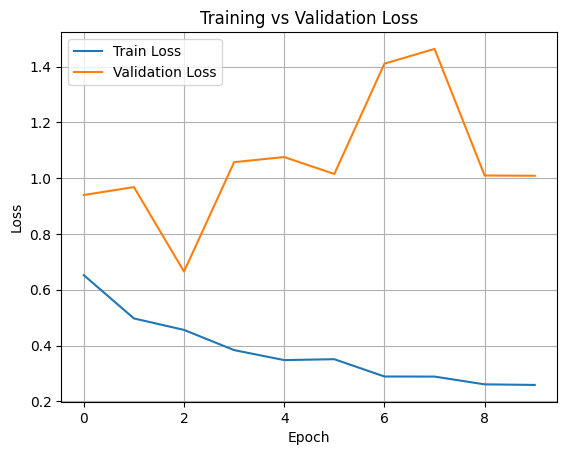

In [31]:
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


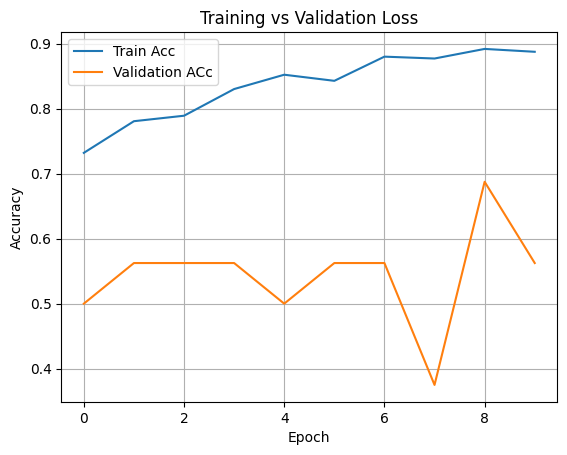

In [35]:
plt.plot(epoch_count, train_acc_values, label="Train Acc")
plt.plot(epoch_count, test_acc_values, label="Validation ACc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [36]:
best_model = model.to(device)
best_model.load_state_dict(torch.load("best_model.pth"))

/tmp/ipykernel_31/3624963139.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_model.pth"))


<All keys matched successfully>

In [37]:
test_acc, test_loss = evaluate_model(best_model, test_loader, Loss_fn)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")


Final Test Accuracy: 0.7188
Final Test Loss: 0.7520
